In [2]:
from datasets import load_dataset

dataset = load_dataset("FinanceMTEB/financial_phrasebank")
print(dataset)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label_text', 'label'],
        num_rows: 1264
    })
    test: Dataset({
        features: ['text', 'label_text', 'label'],
        num_rows: 1000
    })
})
{'text': 'The Samsung Mobile Applications Store was launched in January 2009 by Samsung Mobile Innovator , a program which enables mobile software developers to create applications for use across Samsung mobile devices .', 'label_text': 'neutral', 'label': 1}


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])

print("=== TRAIN ===")
print(f"Total frases: {len(df_train)}")
print("\nDistribución de clases:")
print(df_train["label_text"].value_counts())
print("\nPorcentajes:")
print(df_train["label_text"].value_counts(normalize=True).round(3) * 100)

=== TRAIN ===
Total frases: 1264

Distribución de clases:
label_text
neutral     779
positive    320
negative    165
Name: count, dtype: int64

Porcentajes:
label_text
neutral     61.6
positive    25.3
negative    13.1
Name: proportion, dtype: float64


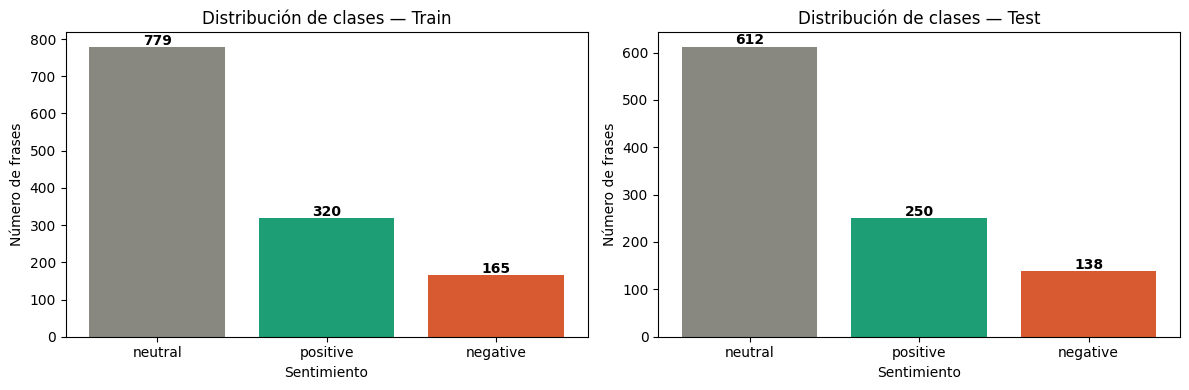

Gráfica guardada en notebook/distribucion_clases.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colores = {"neutral": "#888780", "positive": "#1D9E75", "negative": "#D85A30"}

for ax, (split, df) in zip(axes, [("Train", df_train), ("Test", df_test)]):
    conteos = df["label_text"].value_counts()
    ax.bar(conteos.index, conteos.values, 
           color=[colores[c] for c in conteos.index])
    ax.set_title(f"Distribución de clases — {split}")
    ax.set_xlabel("Sentimiento")
    ax.set_ylabel("Número de frases")
    for i, v in enumerate(conteos.values):
        ax.text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada en notebook/distribucion_clases.png")


In [7]:
print("=== EJEMPLOS POR CATEGORÍA ===\n")

for categoria in ["positive", "negative", "neutral"]:
    ejemplos = df_train[df_train["label_text"] == categoria]["text"].head(3)
    print(f"--- {categoria.upper()} ---")
    for ejemplo in ejemplos:
        print(f"  • {ejemplo}")
    print()

=== EJEMPLOS POR CATEGORÍA ===

--- POSITIVE ---
  • Savon koulutuskuntayhtyma , Finland based company has awarded contract for specialist agricultural or forestry machinery .
  • BasWare 's CEO Ilkka Sihvo comments in conjunction with the Interim Report : `` As a whole , BasWare succeeded well in the second quarter of 2007 .
  • That would be an increase from estimated sales of 117 million last year .

--- NEGATIVE ---
  • Finnish Bank of +àland reports operating profit of EUR 2.2 mn in the first quarter of 2010 , down from EUR 6.3 mn in the corresponding period in 2009 .
  • Cash flow after investments amounted to EUR45m , down from EUR46m .
  • Finnish media group Talentum has issued a profit warning .

--- NEUTRAL ---
  • The Samsung Mobile Applications Store was launched in January 2009 by Samsung Mobile Innovator , a program which enables mobile software developers to create applications for use across Samsung mobile devices .
  • F-Secure , a developer of security solutions as a

=== LONGITUD DE LOS TEXTOS (palabras) ===
Media: 22.3 palabras
Máximo: 81 palabras
Mínimo: 2 palabras
Frases con más de 100 palabras: 0


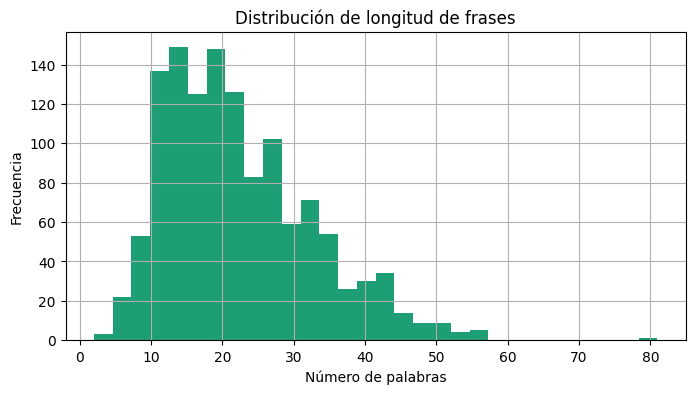

In [8]:
df_train["longitud"] = df_train["text"].apply(lambda x: len(x.split()))

print("=== LONGITUD DE LOS TEXTOS (palabras) ===")
print(f"Media: {df_train['longitud'].mean():.1f} palabras")
print(f"Máximo: {df_train['longitud'].max()} palabras")
print(f"Mínimo: {df_train['longitud'].min()} palabras")
print(f"Frases con más de 100 palabras: {(df_train['longitud'] > 100).sum()}")

df_train["longitud"].hist(bins=30, figsize=(8, 4), color="#1D9E75")
plt.title("Distribución de longitud de frases")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.savefig("distribucion_longitud.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
import numpy as np

total = len(df_train)
conteos = df_train["label_text"].value_counts()

pesos = {}
for clase, conteo in conteos.items():
    pesos[clase] = round(total / (3 * conteo), 4)

print("=== CLASS WEIGHTS PARA EL ENTRENAMIENTO ===")
for clase, peso in pesos.items():
    print(f"  {clase}: {peso}")

print("\nInterpretación:")
print("Un peso mayor significa que el modelo penaliza más los errores en esa clase")
print("La clase 'negative' tiene el peso más alto porque es la más difícil de aprender")

=== CLASS WEIGHTS PARA EL ENTRENAMIENTO ===
  neutral: 0.5409
  positive: 1.3167
  negative: 2.5535

Interpretación:
Un peso mayor significa que el modelo penaliza más los errores en esa clase
La clase 'negative' tiene el peso más alto porque es la más difícil de aprender
